# **NHANES Data Analysis using Numpy**




**STEP 1: Data Collection**
  
  In this step,the NHANES dataset for  adult males and females is downloaded and prepared for analysis.The dataset contains body measurements  such as weight,height and circumferences.

**STEP 2: Reading data as Numpy Matrices**


In [53]:
import numpy as np
male=np.genfromtxt("nhanes_adult_male_bmx_2020.csv",delimiter=',',skip_header=1)
female=np.genfromtxt("nhanes_adult_female_bmx_2020.csv",delimiter=',',skip_header=1)
print(male.shape)
print(female.shape)


(4082, 7)
(4222, 7)


Explanation:

  The CSV files are read and converted into Numpy Matrices.Each row represents an individual,and each column represents a specific body measurement.

**STEP 3: Histogram Visualization**

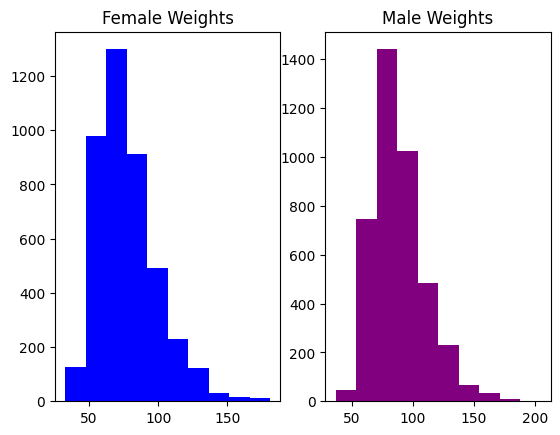

In [54]:
import matplotlib.pyplot as plt
male_weights=male[:,0]
female_weights=female[:,0]
plt.subplot(1,2,1)
plt.hist(female_weights,color='blue')
plt.title("Female Weights")

plt.subplot(1,2,2)
plt.hist(male_weights,color='purple')
plt.title("Male Weights")

plt.show()

Explanation:

Histograms are plotted to visualize the distributio of male and female weights. This helps in understanding how the weights are distributed across the population.

S**TEP 4: Boxplot Comparison**

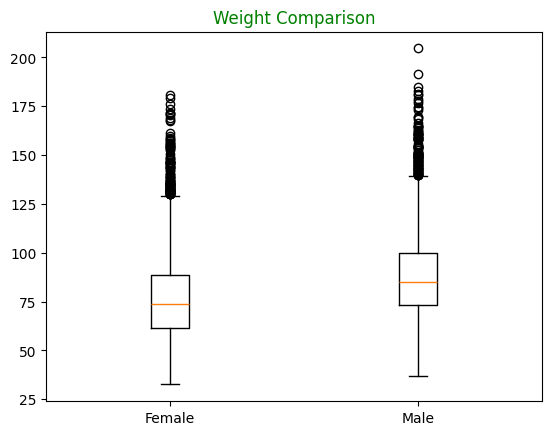

In [55]:
import matplotlib.pyplot as plt
import numpy as np

male_weights = male[:,0]
female_weights = female[:,0]

# REMOVE NaN values
male_weights = male_weights[~np.isnan(male_weights)]
female_weights = female_weights[~np.isnan(female_weights)]

plt.figure()

plt.boxplot([female_weights, male_weights])
plt.xticks([1,2], ['Female', 'Male'])
plt.title("Weight Comparison",color='green')

plt.show()

Explanation:

Boxplots are used to compare male and female  weight distribution.They shows the median,spread and presence of outliers  in the data.

**STEP 5: Numerical aggregates**

In [56]:
import numpy as np

male_weights = male[:,0]
female_weights = female[:,0]

male_weights = male_weights[~np.isnan(male_weights)]
female_weights = female_weights[~np.isnan(female_weights)]

print("Male Mean:", np.mean(male_weights))
print("Female Mean:", np.mean(female_weights))

print("Male Std:", np.std(male_weights))
print("Female Std:", np.std(female_weights))

Male Mean: 88.36454300416565
Female Mean: 77.40379057095475
Male Std: 21.418936717962495
Female Std: 21.54250829019315


Explanation:

Statistical measures such as mean and standard deviation are calculated to  summarize the central tendency and variablility of male and  female  weights.

**STEP 6: Body Mass Index(BMI) calculation**

In [57]:
height=female[:,1]/100
bmi=female[:,0]/(height**2)
female=np.column_stack((female,bmi))
female=female[~np.isnan(female).any(axis=1)]
print(female[:5])

[[ 97.1        160.2         34.7         40.8         35.8
  126.1        117.9         37.83504078]
 [ 91.1        152.7         33.5         33.          38.5
  125.5        103.1         39.06972037]
 [ 73.         161.2         37.4         38.          31.8
  106.2         92.          28.09265496]
 [ 61.7        157.4         38.          34.7         29.
  101.          90.5         24.90437849]
 [ 55.4        154.6         34.6         34.          28.3
   92.5         73.2         23.17879132]]


Explanation:

BMI is calculated using weight and height for female participants and added as a new column to the dataset for further analysis.

**STEP 7: Data standardization(zcore)**

In [58]:
female_clean=female[~np.isnan(female).any(axis=1)]
mean=np.mean(female_clean,axis=0)
std=np.std(female_clean,axis=0)
zfemale=(female_clean-mean)/std
print(zfemale[:5])

[[ 0.91429508  0.00895038 -0.56739463  1.13298804  0.55084546  1.08316157
   1.11578462  0.9969677 ]
 [ 0.63577599 -1.05306843 -1.07893145 -1.29349161  1.03221804  1.04475528
   0.265089    1.15617483]
 [-0.2044233   0.15055289  0.5835632   0.26194406 -0.1622991  -0.19064688
  -0.37293272 -0.25927501]
 [-0.7289676  -0.38753664  0.83933161 -0.76464348 -0.66150029 -0.52350135
  -0.45915188 -0.67039085]
 [-1.02141265 -0.78402366 -0.6100227  -0.98240447 -0.78630059 -1.06759039
  -1.45354609 -0.89289859]]


Explanation:

This dataset is standarized  using z-scores so  that all variables have a mean of 0 and standard deviation of 1. This allows fair comparison between variables.

**STEP 8: Scatterplot Matrix and Correlation Analysis**

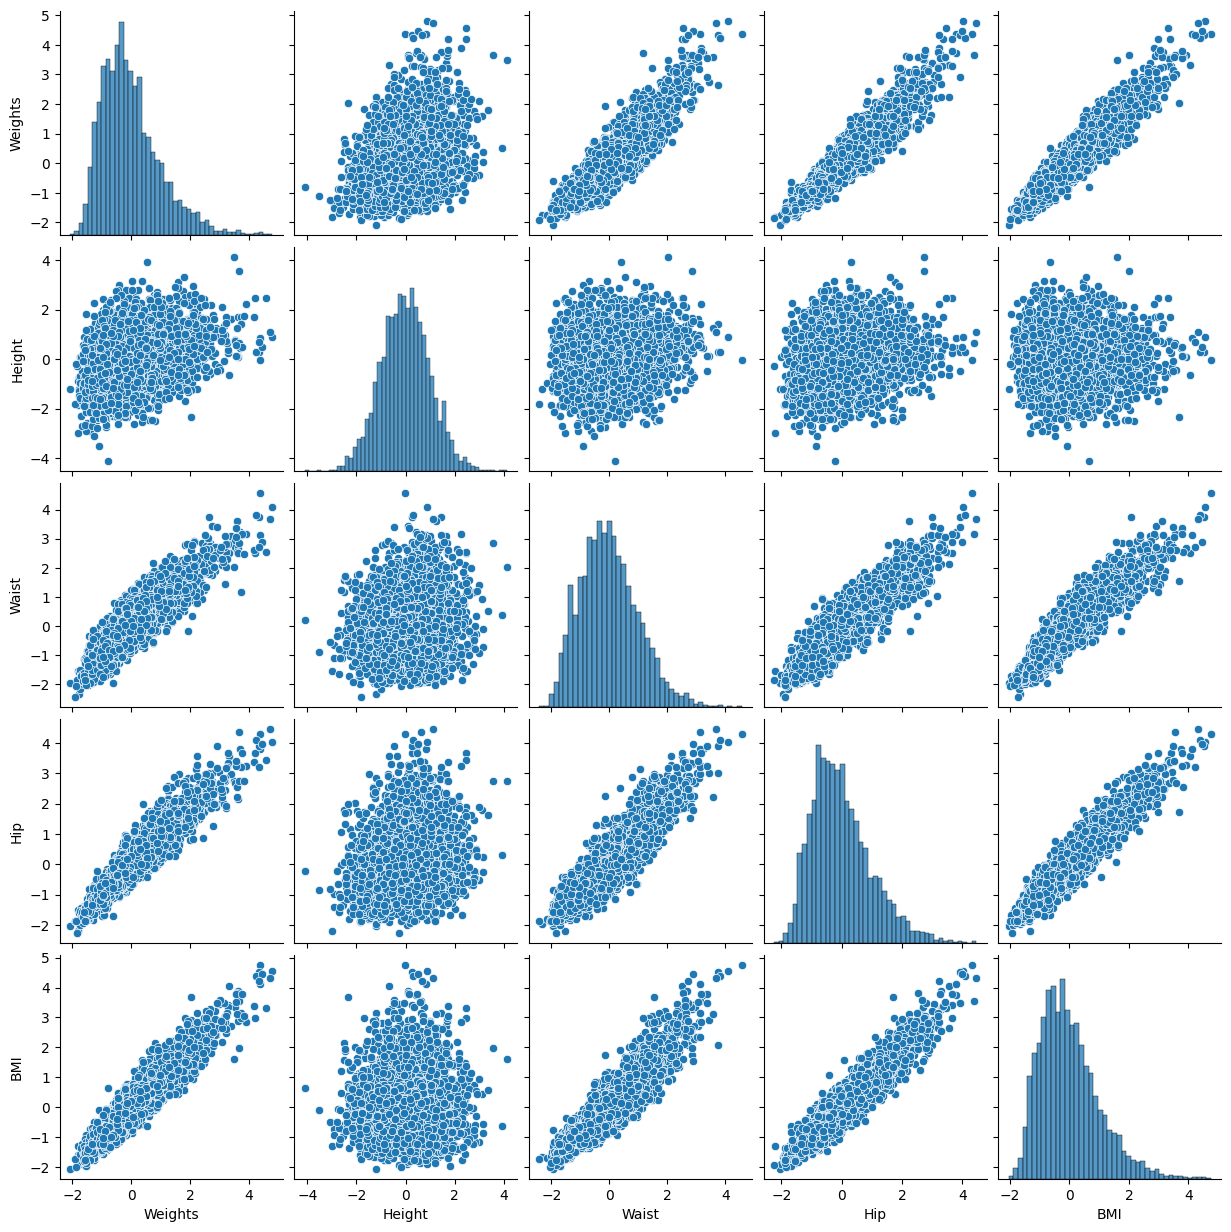

Pearson Correlation:
           Weights    Height     Waist       Hip       BMI
Weights  1.000000  0.345496  0.904550  0.946553  0.945900
Height   0.345496  1.000000  0.126547  0.202895  0.033077
Waist    0.904550  0.126547  1.000000  0.897407  0.921198
Hip      0.946553  0.202895  0.897407  1.000000  0.944199
BMI      0.945900  0.033077  0.921198  0.944199  1.000000
Spearman Correlation:
           Weights    Height     Waist       Hip       BMI
Weights  1.000000  0.338860  0.900169  0.946634  0.937999
Height   0.338860  1.000000  0.108587  0.205405  0.019897
Waist    0.900169  0.108587  1.000000  0.888037  0.923114
Hip      0.946634  0.205405  0.888037  1.000000  0.934196
BMI      0.937999  0.019897  0.923114  0.934196  1.000000


In [59]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
#select required columns from standardized data
data=zfemale[:,[0,1,6,5,7]]
#create dataframe
df=pd.DataFrame(data,columns=['Weights','Height','Waist','Hip','BMI'])
#pairplot(scatterplot matrix)
sns.pairplot(df)
plt.show()
#correlation
print("Pearson Correlation:\n",df.corr(method='pearson'))
print("Spearman Correlation:\n",df.corr(method='spearman'))

Expalanation:
   
   A Pairplot (scatterplot matrix) is created to visualize relationships between variables such as weight,height,hip,BMI.Correlation coefficients are calculated to measure the strength of thease relationships.


**STEP 9: Ratio Calculations**

In [60]:
male_clean=male[~np.isnan(male).any(axis=1)]
female_clean=female[~np.isnan(female).any(axis=1)]
male_ratio1=male_clean[:,6]/male_clean[:,1]
male_ratio2=male_clean[:,6]/male_clean[:,5]
female_ratio1=female_clean[:,6]/female_clean[:,1]
female_ratio2=female_clean[:,6]/female_clean[:,5]
print("Male Waist/Height:",male_ratio1[:5])
print("Male Waist/Height:",male_ratio2[:5])
print("Female Waist/Height:",female_ratio1[:5])
print("Female Waist/Height:",female_ratio2[:5])

Male Waist/Height: [0.66044981 0.47122693 0.59147329 0.6454112  0.58920705]
Male Waist/Height: [1.11275416 0.91851852 1.01669759 1.01785714 0.89018303]
Female Waist/Height: [0.73595506 0.67518009 0.5707196  0.57496823 0.47347995]
Female Waist/Height: [0.93497224 0.82151394 0.86629002 0.8960396  0.79135135]


Explanation:

Waist-to-height and waist -to-hip ratios are computed for both male and female participants.These ratios are useful indicators of body fat distribution and health risk.

**STEP 10: Boxplot of Ratios**

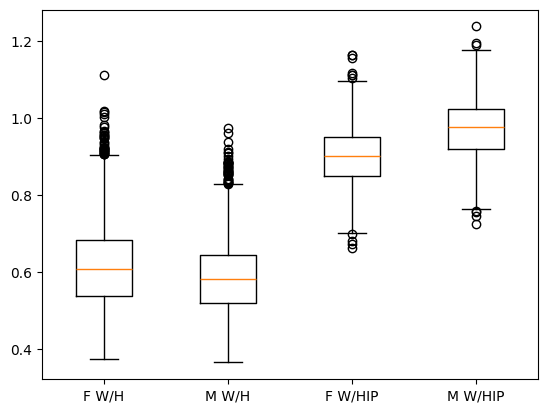

In [61]:
plt.boxplot([female_ratio1,male_ratio1,female_ratio2,male_ratio2])
plt.xticks([1,2,3,4],['F W/H','M W/H','F W/HIP',"M W/HIP"])
plt.show()

Explanation:

Boxplots are used to compare the distribution of waist-to-height and waist-to-hip ratios between male and female participants.

**STEP 11:** **Advantages and Disadvantages of Measures:**

  **1.Body Mass Index(BMI)**

  Advantages:
*   Simple and easy to calculate.
*   Requires  only weight and height.
*   Useful for large population studies.
*   Helps classify underweight,normal,overweight and obese.
  
  Disadvantages:
*   Does not disguish between fat and muscle.
*   Athlets maybe misclassified.
*   Does not show fat distribution.
*   Less accurate for individuals.

 **2.Waist-to-Height Ratio(WHtR)**
  
  Advantages:
*   Better indicator of health risk then BMI.
*   Focuses on abdominal fat.
*   Simple and easy to calculate.
*   applicable for different age groups.
  
  Disadvantages:
*   Requires accurate waist measurement.
*   Small errors can affect result.
*   Does not measure total body fat.

  **3.Waist-to-Hip Ratio(WHR)**
  
  Advantages:
*   Shows fat distribution clearly.
*   Helps identify abdominal obesity.
*   Useful for predicting heart disease risk.
  
  Disadvantages:
*   Needs two measurement(waist&hip).
*   Measurement errors  possible.
*   Does not indicate total body fat.


**STEP 12: Analysis of Extreme BMI Values**

In [62]:
bmi_values=zfemale[:,7]
sorted_index=np.argsort(bmi_values)
print("Lowest BMI:\n",zfemale[sorted_index[:5]])
print("Highest BMI:\n",zfemale[sorted_index[:5]])

Lowest BMI:
 [[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577]]
Highest BMI:
 [[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82

Explanation:
  
  The standardized data of individuals with the lowest and highest BMI values are analyzed.This helps in identifying patterns among underweight and overweight individuals.